<a href="https://colab.research.google.com/github/xiyuan1avery/ma2288/blob/research-v2/notebooks/15_v2_train_onpolicy_latent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers pandas matplotlib

In [2]:
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import (
    DataLoader,
    TensorDataset,
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cuda


In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
DRIVE_DIRECTORY = Path(
    "/content/drive/MyDrive/ma2288_nextlat"
)

ONPOLICY_DATA_PATH = (
    DRIVE_DIRECTORY
    / "data_v2"
    / "onpolicy_rollouts_seed42.pt"
)

MULTISTEP_CHECKPOINT_PATH = (
    DRIVE_DIRECTORY
    / "checkpoints"
    / "multistep_transition_seed42.pt"
)

print("Data:", ONPOLICY_DATA_PATH.exists())
print(
    "Checkpoint:",
    MULTISTEP_CHECKPOINT_PATH.exists(),
)

Data: True
Checkpoint: True


In [5]:
artifact = torch.load(
    ONPOLICY_DATA_PATH,
    map_location="cpu",
    weights_only=False,
)

initial_hidden = artifact[
    "initial_hidden"
]

draft_token_ids = artifact[
    "draft_token_ids"
]

target_hidden_states = artifact[
    "target_hidden_states"
]

prompt_indices = artifact[
    "prompt_indices"
]

MODEL_NAME = artifact[
    "model_name"
]

ROLLOUT_LENGTH = artifact[
    "rollout_length"
]

print("Initial hidden:", initial_hidden.shape)
print("Draft tokens:", draft_token_ids.shape)
print(
    "Target hidden:",
    target_hidden_states.shape,
)
print("Rollout length:", ROLLOUT_LENGTH)

Initial hidden: torch.Size([800, 768])
Draft tokens: torch.Size([800, 8])
Target hidden: torch.Size([800, 8, 768])
Rollout length: 8


In [6]:
unique_prompt_indices = torch.unique(
    prompt_indices
)

split_generator = torch.Generator()
split_generator.manual_seed(SEED)

permutation = torch.randperm(
    len(unique_prompt_indices),
    generator=split_generator,
)

shuffled_prompts = (
    unique_prompt_indices[
        permutation
    ]
)

number_of_train_prompts = int(
    0.8 * len(shuffled_prompts)
)

train_prompt_ids = shuffled_prompts[
    :number_of_train_prompts
]

validation_prompt_ids = shuffled_prompts[
    number_of_train_prompts:
]

train_mask = torch.isin(
    prompt_indices,
    train_prompt_ids,
)

validation_mask = torch.isin(
    prompt_indices,
    validation_prompt_ids,
)

print(
    "Train prompts:",
    len(train_prompt_ids),
)

print(
    "Validation prompts:",
    len(validation_prompt_ids),
)

print(
    "Train chains:",
    train_mask.sum().item(),
)

print(
    "Validation chains:",
    validation_mask.sum().item(),
)

Train prompts: 320
Validation prompts: 80
Train chains: 640
Validation chains: 160


In [7]:
train_dataset = TensorDataset(
    initial_hidden[train_mask],
    draft_token_ids[train_mask],
    target_hidden_states[train_mask],
)

validation_dataset = TensorDataset(
    initial_hidden[validation_mask],
    draft_token_ids[
        validation_mask
    ],
    target_hidden_states[
        validation_mask
    ],
)

BATCH_SIZE = 64

train_generator = torch.Generator()
train_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=train_generator,
    num_workers=0,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print("Train batches:", len(train_loader))
print(
    "Validation batches:",
    len(validation_loader),
)

Train batches: 10
Validation batches: 3


In [8]:
from transformers import (
    AutoModelForCausalLM,
)

target_model = (
    AutoModelForCausalLM
    .from_pretrained(MODEL_NAME)
    .to(device)
)

target_model.eval()

for parameter in target_model.parameters():
    parameter.requires_grad = False

token_embedding = (
    target_model.get_input_embeddings()
)

print("Token embedding loaded.")

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Token embedding loaded.


In [9]:
class ResidualTransitionMLP(nn.Module):
    def __init__(
        self,
        hidden_dimension=768,
        bottleneck_dimension=512,
    ):
        super().__init__()

        combined_dimension = (
            hidden_dimension * 2
        )

        self.input_normalization = nn.LayerNorm(
            combined_dimension
        )

        self.network = nn.Sequential(
            nn.Linear(
                combined_dimension,
                bottleneck_dimension,
            ),
            nn.GELU(),
            nn.Linear(
                bottleneck_dimension,
                hidden_dimension,
            ),
        )

    def forward(
        self,
        current_hidden,
        next_token_embedding,
    ):
        combined = torch.cat(
            [
                current_hidden,
                next_token_embedding,
            ],
            dim=-1,
        )

        delta = self.network(
            self.input_normalization(
                combined
            )
        )

        return current_hidden + delta

In [10]:
base_checkpoint = torch.load(
    MULTISTEP_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

transition_model = ResidualTransitionMLP(
    hidden_dimension=base_checkpoint[
        "hidden_dimension"
    ],
    bottleneck_dimension=base_checkpoint[
        "bottleneck_dimension"
    ],
)

transition_model.load_state_dict(
    base_checkpoint[
        "model_state_dict"
    ]
)

transition_model = transition_model.to(
    device
)

print(
    "Initialized from:",
    MULTISTEP_CHECKPOINT_PATH.name,
)

Initialized from: multistep_transition_seed42.pt


In [11]:
def compute_recursive_latent_loss(
    transition_model,
    batch_initial_hidden,
    batch_token_ids,
    batch_target_hidden,
):
    current_prediction = (
        batch_initial_hidden
        .float()
        .to(device)
    )

    batch_token_ids = (
        batch_token_ids.to(device)
    )

    batch_target_hidden = (
        batch_target_hidden
        .float()
        .to(device)
    )

    total_loss = 0.0
    step_losses = []
    step_normalized_l2 = []

    for step in range(
        ROLLOUT_LENGTH
    ):
        next_token_ids = (
            batch_token_ids[:, step]
        )

        with torch.no_grad():
            next_embeddings = (
                token_embedding(
                    next_token_ids
                )
            )

        current_prediction = (
            transition_model(
                current_prediction,
                next_embeddings,
            )
        )

        target_hidden = (
            batch_target_hidden[
                :,
                step,
                :,
            ]
        )

        step_loss = F.smooth_l1_loss(
            current_prediction,
            target_hidden,
            reduction="mean",
        )

        total_loss = (
            total_loss + step_loss
        )

        difference_norm = (
            torch.linalg.vector_norm(
                current_prediction
                - target_hidden,
                dim=-1,
            )
        )

        target_norm = (
            torch.linalg.vector_norm(
                target_hidden,
                dim=-1,
            )
        )

        normalized_l2 = (
            difference_norm
            / (target_norm + 1e-8)
        )

        step_losses.append(
            step_loss
        )

        step_normalized_l2.append(
            normalized_l2.mean()
        )

    mean_loss = (
        total_loss / ROLLOUT_LENGTH
    )

    return (
        mean_loss,
        step_losses,
        step_normalized_l2,
    )

In [12]:
def evaluate_model(
    transition_model,
):
    transition_model.eval()

    total_loss = 0.0
    total_chains = 0

    step_loss_sums = torch.zeros(
        ROLLOUT_LENGTH
    )

    step_l2_sums = torch.zeros(
        ROLLOUT_LENGTH
    )

    with torch.no_grad():
        for (
            batch_initial,
            batch_tokens,
            batch_targets,
        ) in validation_loader:

            (
                loss,
                step_losses,
                step_l2,
            ) = compute_recursive_latent_loss(
                transition_model,
                batch_initial,
                batch_tokens,
                batch_targets,
            )

            batch_size = (
                batch_initial.shape[0]
            )

            total_loss += (
                loss.item() * batch_size
            )

            total_chains += batch_size

            for step in range(
                ROLLOUT_LENGTH
            ):
                step_loss_sums[step] += (
                    step_losses[step]
                    .item()
                    * batch_size
                )

                step_l2_sums[step] += (
                    step_l2[step]
                    .item()
                    * batch_size
                )

    return {
        "mean_loss": (
            total_loss
            / total_chains
        ),
        "step_losses": (
            step_loss_sums
            / total_chains
        ).tolist(),
        "step_normalized_l2": (
            step_l2_sums
            / total_chains
        ).tolist(),
    }

In [13]:
baseline_validation_metrics = (
    evaluate_model(
        transition_model
    )
)

print(
    "Before on-policy fine-tuning:"
)

print(
    baseline_validation_metrics
)

Before on-policy fine-tuning:
{'mean_loss': 0.1394230991601944, 'step_losses': [0.11559818685054779, 0.13723652064800262, 0.1422940492630005, 0.14634570479393005, 0.138652041554451, 0.14097057282924652, 0.14485116302967072, 0.1494365632534027], 'step_normalized_l2': [0.2216772586107254, 0.2293376922607422, 0.22868534922599792, 0.20692801475524902, 0.1949141025543213, 0.20329804718494415, 0.18709905445575714, 0.21209213137626648]}


In [14]:
LEARNING_RATE = 1e-4
MAX_EPOCHS = 20
PATIENCE = 4

optimizer = torch.optim.AdamW(
    transition_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4,
)

best_validation_loss = (
    baseline_validation_metrics[
        "mean_loss"
    ]
)

best_model_state = copy.deepcopy(
    transition_model.state_dict()
)

epochs_without_improvement = 0
training_history = []

In [15]:
for epoch in range(
    1,
    MAX_EPOCHS + 1,
):
    transition_model.train()

    total_train_loss = 0.0
    total_train_chains = 0

    for (
        batch_initial,
        batch_tokens,
        batch_targets,
    ) in train_loader:

        (
            loss,
            _,
            _,
        ) = compute_recursive_latent_loss(
            transition_model,
            batch_initial,
            batch_tokens,
            batch_targets,
        )

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            transition_model.parameters(),
            max_norm=1.0,
        )

        optimizer.step()

        batch_size = (
            batch_initial.shape[0]
        )

        total_train_loss += (
            loss.item() * batch_size
        )

        total_train_chains += batch_size

    mean_train_loss = (
        total_train_loss
        / total_train_chains
    )

    validation_metrics = (
        evaluate_model(
            transition_model
        )
    )

    validation_loss = (
        validation_metrics[
            "mean_loss"
        ]
    )

    training_history.append({
        "epoch": epoch,
        "train_loss": (
            mean_train_loss
        ),
        "validation_loss": (
            validation_loss
        ),
        "validation_step_1_l2": (
            validation_metrics[
                "step_normalized_l2"
            ][0]
        ),
        "validation_step_4_l2": (
            validation_metrics[
                "step_normalized_l2"
            ][3]
        ),
        "validation_step_8_l2": (
            validation_metrics[
                "step_normalized_l2"
            ][7]
        ),
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train={mean_train_loss:.6f} | "
        f"validation={validation_loss:.6f} | "
        f"L2 step1="
        f"{validation_metrics['step_normalized_l2'][0]:.4f} | "
        f"step4="
        f"{validation_metrics['step_normalized_l2'][3]:.4f} | "
        f"step8="
        f"{validation_metrics['step_normalized_l2'][7]:.4f}"
    )

    if (
        validation_loss
        < best_validation_loss
    ):
        best_validation_loss = (
            validation_loss
        )

        best_model_state = copy.deepcopy(
            transition_model.state_dict()
        )

        epochs_without_improvement = 0
        print("  New best model.")

    else:
        epochs_without_improvement += 1

        print(
            "  Epochs without improvement:",
            epochs_without_improvement,
        )

    if (
        epochs_without_improvement
        >= PATIENCE
    ):
        print("Early stopping.")
        break

Epoch 01 | train=0.139629 | validation=0.137828 | L2 step1=0.2227 | step4=0.2003 | step8=0.2085
  New best model.
Epoch 02 | train=0.136470 | validation=0.136533 | L2 step1=0.2241 | step4=0.2020 | step8=0.2089
  New best model.
Epoch 03 | train=0.135145 | validation=0.136430 | L2 step1=0.2243 | step4=0.2031 | step8=0.2125
  New best model.
Epoch 04 | train=0.133797 | validation=0.136289 | L2 step1=0.2242 | step4=0.1987 | step8=0.2048
  New best model.
Epoch 05 | train=0.132437 | validation=0.136345 | L2 step1=0.2245 | step4=0.1983 | step8=0.2042
  Epochs without improvement: 1
Epoch 06 | train=0.131502 | validation=0.135738 | L2 step1=0.2244 | step4=0.1993 | step8=0.2059
  New best model.
Epoch 07 | train=0.130785 | validation=0.135679 | L2 step1=0.2244 | step4=0.1983 | step8=0.2039
  New best model.
Epoch 08 | train=0.129957 | validation=0.135876 | L2 step1=0.2242 | step4=0.1980 | step8=0.2027
  Epochs without improvement: 1
Epoch 09 | train=0.129235 | validation=0.136964 | L2 step1=0

In [16]:
transition_model.load_state_dict(
    best_model_state
)

best_validation_metrics = (
    evaluate_model(
        transition_model
    )
)

print("\nBefore fine-tuning:")
print(
    baseline_validation_metrics
)

print("\nAfter fine-tuning:")
print(
    best_validation_metrics
)

relative_loss_reduction = (
    100
    * (
        baseline_validation_metrics[
            "mean_loss"
        ]
        - best_validation_metrics[
            "mean_loss"
        ]
    )
    / baseline_validation_metrics[
        "mean_loss"
    ]
)

print(
    "\nRelative validation loss "
    f"reduction: "
    f"{relative_loss_reduction:.2f}%"
)


Before fine-tuning:
{'mean_loss': 0.1394230991601944, 'step_losses': [0.11559818685054779, 0.13723652064800262, 0.1422940492630005, 0.14634570479393005, 0.138652041554451, 0.14097057282924652, 0.14485116302967072, 0.1494365632534027], 'step_normalized_l2': [0.2216772586107254, 0.2293376922607422, 0.22868534922599792, 0.20692801475524902, 0.1949141025543213, 0.20329804718494415, 0.18709905445575714, 0.21209213137626648]}

After fine-tuning:
{'mean_loss': 0.13533176183700563, 'step_losses': [0.11563502252101898, 0.13563092052936554, 0.13894402980804443, 0.1412593424320221, 0.1327400505542755, 0.13667087256908417, 0.13946710526943207, 0.14230670034885406], 'step_normalized_l2': [0.22425194084644318, 0.2296876460313797, 0.22614309191703796, 0.1993529498577118, 0.1878013163805008, 0.19817592203617096, 0.1804772913455963, 0.2018878012895584]}

Relative validation loss reduction: 2.93%


In [17]:
CHECKPOINT_DIRECTORY = (
    DRIVE_DIRECTORY
    / "checkpoints_v2"
)

CHECKPOINT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

CHECKPOINT_PATH = (
    CHECKPOINT_DIRECTORY
    / "onpolicy_latent_transition_seed42.pt"
)

new_checkpoint = {
    "model_state_dict": (
        transition_model.state_dict()
    ),
    "model_name": MODEL_NAME,
    "hidden_dimension": 768,
    "bottleneck_dimension": 512,
    "seed": SEED,
    "rollout_length": (
        ROLLOUT_LENGTH
    ),
    "learning_rate": (
        LEARNING_RATE
    ),
    "initial_checkpoint": (
        "multistep_transition_seed42.pt"
    ),
    "training_data": (
        "onpolicy_rollouts_seed42.pt"
    ),
    "best_validation_loss": (
        best_validation_loss
    ),
    "baseline_validation_metrics": (
        baseline_validation_metrics
    ),
    "best_validation_metrics": (
        best_validation_metrics
    ),
    "training_history": (
        training_history
    ),
}

torch.save(
    new_checkpoint,
    CHECKPOINT_PATH,
)

print("Saved:", CHECKPOINT_PATH)

Saved: /content/drive/MyDrive/ma2288_nextlat/checkpoints_v2/onpolicy_latent_transition_seed42.pt


In [18]:
history_df = pd.DataFrame(
    training_history
)

print(
    history_df.to_string(
        index=False
    )
)

 epoch  train_loss  validation_loss  validation_step_1_l2  validation_step_4_l2  validation_step_8_l2
     1    0.139629         0.137828              0.222725              0.200317              0.208509
     2    0.136470         0.136533              0.224118              0.202014              0.208854
     3    0.135145         0.136430              0.224350              0.203078              0.212533
     4    0.133797         0.136289              0.224232              0.198688              0.204790
     5    0.132437         0.136345              0.224457              0.198296              0.204235
     6    0.131502         0.135738              0.224362              0.199292              0.205933
     7    0.130785         0.135679              0.224418              0.198251              0.203896
     8    0.129957         0.135876              0.224153              0.198044              0.202676
     9    0.129235         0.136964              0.224080              0.198217   

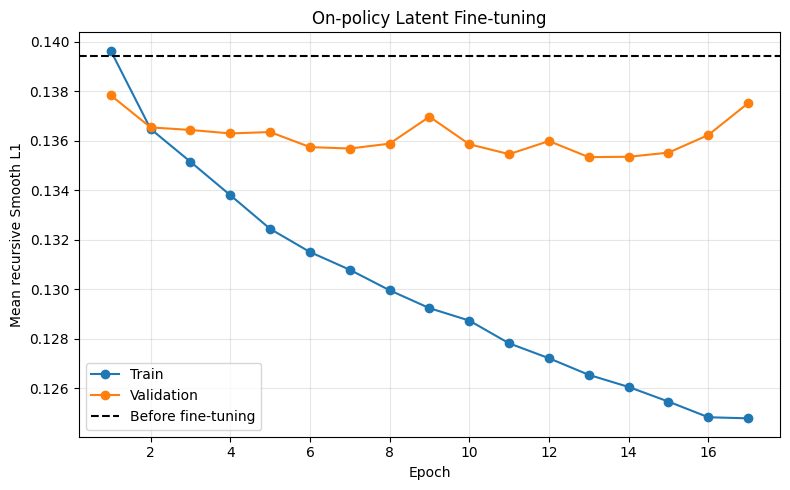

In [19]:
training_figure, axis = plt.subplots(
    figsize=(8, 5)
)

axis.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train",
)

axis.plot(
    history_df["epoch"],
    history_df["validation_loss"],
    marker="o",
    label="Validation",
)

axis.axhline(
    baseline_validation_metrics[
        "mean_loss"
    ],
    color="black",
    linestyle="--",
    label="Before fine-tuning",
)

axis.set_xlabel("Epoch")
axis.set_ylabel(
    "Mean recursive Smooth L1"
)

axis.set_title(
    "On-policy Latent Fine-tuning"
)

axis.legend()
axis.grid(alpha=0.3)

training_figure.tight_layout()
plt.show()

In [20]:
RESULT_DIRECTORY = (
    DRIVE_DIRECTORY
    / "results_v2"
)

TABLE_DIRECTORY = (
    RESULT_DIRECTORY
    / "tables"
)

FIGURE_DIRECTORY = (
    RESULT_DIRECTORY
    / "figures"
)

history_df.to_csv(
    TABLE_DIRECTORY
    / "onpolicy_latent_training.csv",
    index=False,
)

training_figure.savefig(
    FIGURE_DIRECTORY
    / "onpolicy_latent_training.png",
    dpi=250,
    bbox_inches="tight",
)